In [2]:
# STEP 1: Import Required Libraries
# These libraries create the environment for systematic data evaluation
# ------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 3: Load the Dataset
df = pd.read_csv("student.csv")

df.head()

# 4: Data Understanding
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             1000 non-null   int64  
 1   Gender                 1000 non-null   object 
 2   Age                    1000 non-null   int64  
 3   Study_Hours_per_Week   1000 non-null   int64  
 4   Attendance_Percentage  1000 non-null   int64  
 5   Previous_Grade         1000 non-null   int64  
 6   Internet_Usage_Hours   1000 non-null   int64  
 7   Final_Score            1000 non-null   float64
 8   Result                 1000 non-null   object 
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


,Student_ID,Age,Study_Hours_per_Week,Attendance_Percentage,Previous_Grade,Internet_Usage_Hours,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,21.005000,22.062000,74.784000,67.057000,5.046000,42.527430
std,288.819436,2.040377,10.101495,14.454144,15.898507,2.554292,9.365631
min,1.000000,18.000000,5.000000,50.000000,40.000000,1.000000,19.900000
25%,250.750000,19.000000,13.000000,62.000000,54.000000,3.000000,35.745000
50%,500.500000,21.000000,22.000000,75.000000,67.000000,5.000000,42.525000
75%,750.250000,23.000000,31.000000,87.000000,81.000000,7.000000,49.547500
max,1000.000000,24.000000,39.000000,99.000000,94.000000,9.000000,70.480000


In [4]:
# 5: Data Cleaning
# ------------------------------

# Check missing values
df.isnull().sum()

# Fill missing values (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Display confirmation message
print("Cleaning successfully")

Cleaning successfully


In [8]:
# 6: Exploratory Data Analysis (EDA)
# ------------------------------

# Correlation between numerical columns
correlation_matrix = df.corr(numeric_only=True)

# Display correlation 
correlation_matrix

# Create new feature (Performance Category)
df["Performance_Level"] = pd.cut(
    df["Final_Score"],
    bins=[0,40,60,80,100],
    labels=["Poor","Average","Good","Excellent"]
)

df.head()

,Student_ID,Gender,Age,Study_Hours_per_Week,Attendance_Percentage,Previous_Grade,Internet_Usage_Hours,Final_Score,Result,Performance_Level
0,1,Male,23,14,67,80,4,32.73,Fail,Poor
1,2,Female,24,34,98,51,8,46.08,Fail,Average
2,3,Male,18,29,77,88,7,49.32,Fail,Average
3,4,Male,18,24,96,54,9,44.09,Fail,Average
4,5,Male,18,9,60,70,5,31.05,Fail,Poor


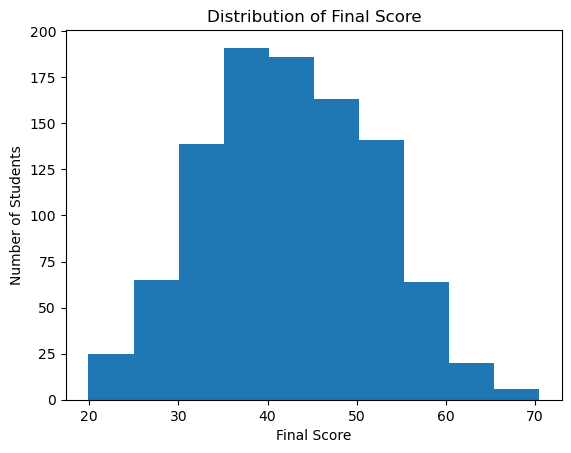

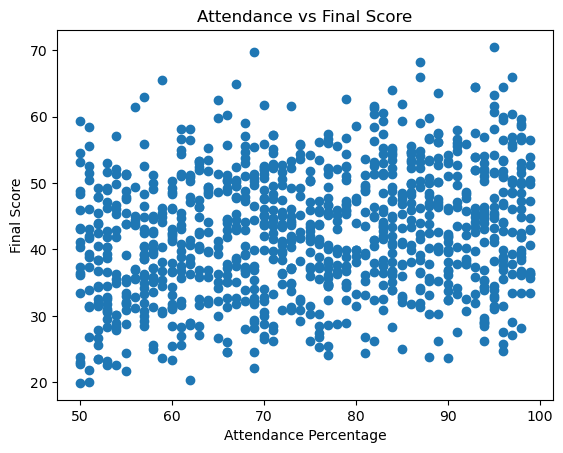

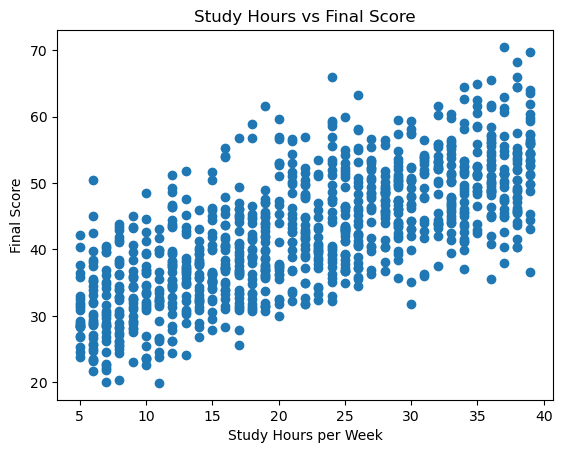

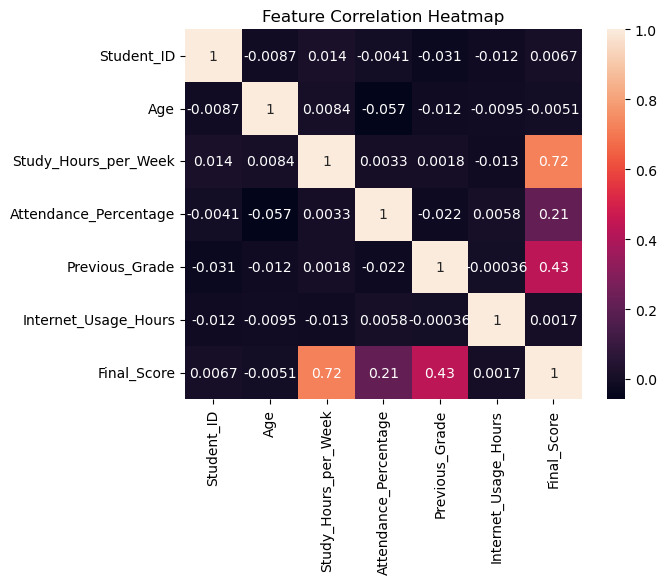

In [9]:
# 7: Data Visualization
# ------------------------------

# 1.Histogram (Final Score Distribution)
plt.hist(df["Final_Score"])

plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

# 2.Attendance vs Final Score (Scatter Plot)
plt.scatter(df["Attendance_Percentage"], df["Final_Score"])

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Score")

plt.show()

# 3.Study Hours vs Final Score
plt.scatter(df["Study_Hours_per_Week"], df["Final_Score"])

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")

plt.show()

# 4.Heatmap (Correlation)
sns.heatmap(correlation_matrix, annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [10]:
# 8: Insight Generation
# ------------------------------

# Top performing students
top_students = df.sort_values(by="Final_Score", ascending=False)

top_students.head()

# Average score
df["Final_Score"].mean()

# Result count
df["Result"].value_counts()

Result
Fail    762
Pass    238
Name: count, dtype: int64

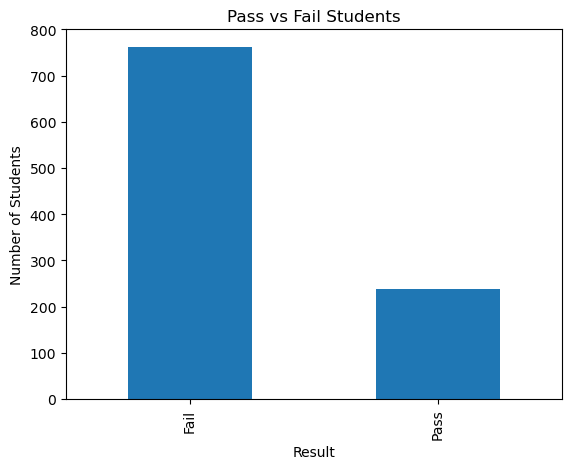

In [11]:
df["Result"].value_counts().plot(kind="bar")

plt.title("Pass vs Fail Students")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

In [12]:
# Save the cleaned and transformed dataset for further analysis
#--------------------------------

df.to_csv("processed_student.csv", index=False)

print("\nProcessed dataset saved successfully.")


Processed dataset saved successfully.
